# Covariance and Correlation
In a distribution involving 2 variables, these values show if and how the values of the variables depend on each other

## Covariance:
Covariance means whether the 2 variables vary in the same direction or the opposite.

- 0: no correlation between the 2 variables.
- +ve value: Positive correlation (x ∝ y). The greater the +ve value, higher the positive correlation
- -ve value: Negative or inverse correlation (x ∝ 1/y). The greater the -ve value, higher the negative correlation

Range of covariance: [-∞, ∞]

However, there is no maximum fixed value for covariance. Hence, determining the degree of covariance (how much is one variable dependent on another) is quite vague.

Hence, we use correlation

## Correlation:
Correlation is the standardized version of covaraince.
Range of correlation: [-1, 1]

- -1: perfect inverse correlation
- 0: No correlation
- +1: perfect correlation

Lets try to first find covariance manually.
The formula for a sample covariance $(s_{xy})$ between two variables, $x$ and $y$, is: 

$s_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$

The Steps:
- Find the mean $(\bar{x})$ of your first dataset (X).
- Find the mean $(\bar{y})$ of your second dataset (Y).
- Subtract the mean from every individual data point for both sets ($(x_{i} - \bar{x})$ and $(y_{i} - \bar{y})$).
- Multiply these two differences together for each pair of data points.
- Sum all of those multiplied products together ($\sum$).
- Divide that total by n - 1 (where n is the total number of data pairs).

Note: For a whole population instead of a sample, divide by n.

np.float64(-0.053452487518126215)

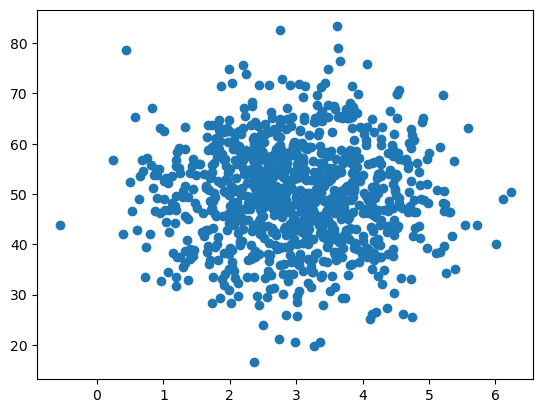

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pylab import *

def de_mean(x):
    xmean = mean(x)
    return [xi - xmean for xi in x]

def covariance(x, y):
    n=len(x)
    return dot(de_mean(x), de_mean(y))/(n-1)

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000)

scatter(pageSpeeds, purchaseAmount)
covariance(pageSpeeds, purchaseAmount)

# plt.show()

Now, lets try and see the effect on covariance if we establish a relationship between pageSpeeds and purchaseAmount

np.float64(-9.185673440177448)

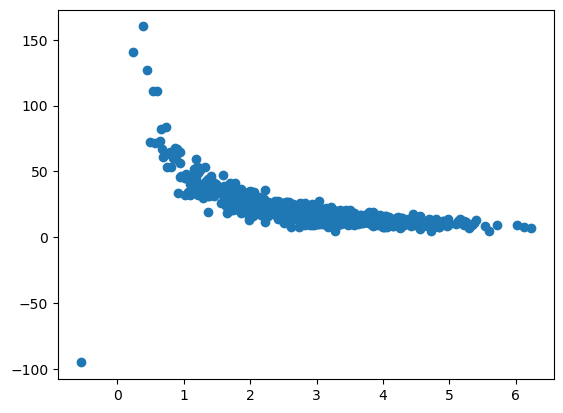

In [6]:
purchaseAmount=np.random.normal(50, 10, 1000) / pageSpeeds
scatter(pageSpeeds, purchaseAmount)
covariance(pageSpeeds, purchaseAmount)


In order to actually interpret the meaning of the value of covariance, we need correlation,
To find correlation, we subsequently divide the covariance by the standard deviations of $x$ and $y$

In [7]:
def correlation(x, y):
    stddevx=x.std()
    stddevy=y.std()
    return covariance(x, y)/stddevx/stddevy # You need to check for 0 here in real life scenario

correlation(pageSpeeds, purchaseAmount)

np.float64(-0.6588489507790022)

By observing the closeness of the resultant value to $-1$ or $+1$, we can determine how closely is the data related to one another.

In numpy, we can find correlation very easily, using the ```numpy.corrcoef```. It returns the correlation coefficients between every combination of the arrays passed in.

In [8]:
np.corrcoef(pageSpeeds, purchaseAmount)

array([[ 1.       , -0.6581901],
       [-0.6581901,  1.       ]])

The 2-d array contains 4 values

- 1st array:
  - 1st value: correlation of pageSpeeds with itself
  - 2nd value: correlation of pageSpeeds with purchaseAmount
- 2nd array:
  - 1st value: correlation of purchaseAmount with pageSpeeds
  - 2nd value: correlation of purchaseAmount with itself

We also have a ```np.cov``` function to calculate covariance between 2 variables. It also produces a 2d matrix, which can be read in the same way as the correlation matrix in the case of ```np.corrcoef```

In [10]:
np.cov(pageSpeeds, purchaseAmount)

array([[ 1.05879712, -3.17639137],
       [-3.17639137,  9.52917412]])

We can also try and force a near perfect correlation. 

***IMP: Correlation does not mean causality. The values may show high value of correlation, but that may not mean they are truly dependant on each other.

np.float64(-1.001001001001001)

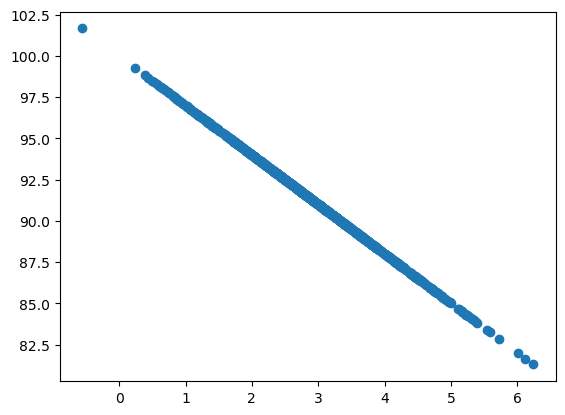

In [9]:
purchaseAmount = 100 - pageSpeeds*3
scatter(pageSpeeds, purchaseAmount)
correlation(pageSpeeds, purchaseAmount)